<a href="https://colab.research.google.com/github/Thangapandi1611/ml-safety-project/blob/main/week7/Explainability_Occulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Packages
import torch
import torch.nn as nn

import numpy as np
import pandas as pd

import cv2

import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision import models

In [1]:
#Mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
#Loading Pedestrain model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_ped = models.resnet18(weights=None)

model_ped.fc = nn.Linear(
    model_ped.fc.in_features,
    1
)

model_ped.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MLS_DATA/pedestrian_model.pth",
        map_location=device
    )
)

model_ped.to(device)

model_ped.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
#Loading Vehicle model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_veh= models.resnet18(weights=None)

model_veh.fc = nn.Linear(
    model_veh.fc.in_features,
    1
)

model_veh.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MLS_DATA/Vehicle_model.pth",
        map_location=device
    )
)

model_veh.to(device)

model_veh.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [31]:
#Loading Traffic Light model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_TL= models.resnet18(weights=None)

model_TL.fc = nn.Linear(
    model_veh.fc.in_features,
    1
)

model_TL.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/MLS_DATA/Traffic_Light_model.pth",
        map_location=device
    )
)

model_TL.to(device)

model_TL.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
#Transform the image
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [37]:
#Loading one image
image_ped = "/content/drive/MyDrive/MLS_DATA/test/rgb-front/001230.jpg"
image_veh= "/content/drive/MyDrive/MLS_DATA/test/rgb-front/001850.jpg"
image_TL= "/content/drive/MyDrive/MLS_DATA/test/rgb-front/000740.jpg"
image_ped = Image.open(image_ped).convert("RGB")
image_veh = Image.open(image_veh).convert("RGB")
image_TL = Image.open(image_TL).convert("RGB")


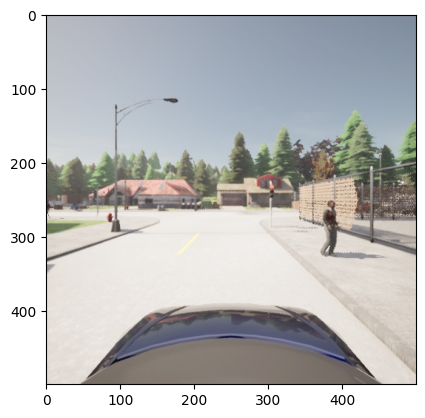

In [38]:
plt.imshow(image_ped)

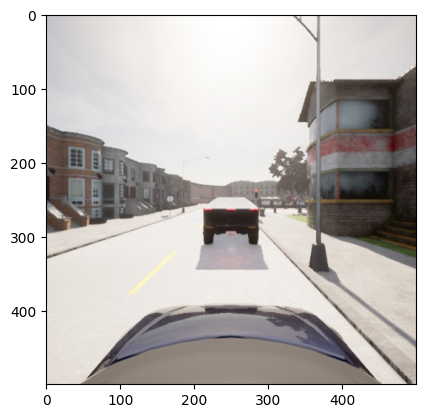

In [39]:
plt.imshow(image_veh)

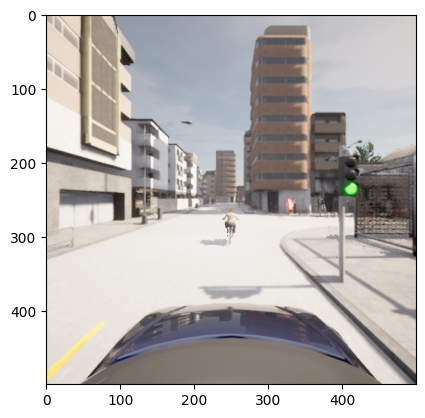

In [40]:
plt.imshow(image_TL)

In [41]:
#Predicting Pedestrain
img_tensor = transform(image_ped)

img_tensor = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():

    output = model_ped(img_tensor)

    prob = torch.sigmoid(output)

print("Original Score Pedestrain:", prob.item())

#Predicting Vehicle

img_tensor = transform(image_veh)

img_tensor = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():

    output = model_veh(img_tensor)

    prob = torch.sigmoid(output)

print("Original Score Vehicle:", prob.item())

#Predicting Pedestrain

img_tensor = transform(image_TL)

img_tensor = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():

    output = model_TL(img_tensor)

    prob = torch.sigmoid(output)

print("Original Score Traffic Light:", prob.item())

Original Score Pedestrain: 0.2771141827106476
Original Score Vehicle: 0.9872720837593079
Original Score Traffic Light: 0.999751627445221


In [42]:
#Occlusion Function
def occlusion_heatmap(image,model,transform,device,patch_size=32,stride=16):
    import numpy as np
    from PIL import Image
    import torch

    # Convert image to numpy array
    img_np = np.array(image)

    H, W, _ = img_np.shape

    # Store importance scores
    heatmap = np.zeros((H, W))

    # Original prediction
    img_tensor = transform(image)
    img_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        original_score = torch.sigmoid(
            model(img_tensor)
        ).item()

    # Slide occlusion window
    for y in range(0, H - patch_size, stride):

        for x in range(0, W - patch_size, stride):

            # Create copy
            occluded = img_np.copy()

            # Hide region
            occluded[
                y:y+patch_size,
                x:x+patch_size
            ] = 0

            # Convert back to image
            occ_img = Image.fromarray(occluded)

            # Preprocess
            occ_tensor = transform(occ_img)
            occ_tensor = occ_tensor.unsqueeze(0).to(device)

            # Predict again
            with torch.no_grad():

                score = torch.sigmoid(
                    model(occ_tensor)
                ).item()

            # Importance
            importance = original_score - score

            # Store score
            heatmap[
                y:y+patch_size,
                x:x+patch_size
            ] += importance

    # Normalize
    heatmap -= heatmap.min()

    heatmap /= (
        heatmap.max() + 1e-8
    )

    return heatmap


In [43]:
#Generate heat maps
heatmap_ped = occlusion_heatmap(
    image_ped,
    model_ped,
    transform,
    device
)
heatmap_veh = occlusion_heatmap(
    image_veh,
    model_veh,
    transform,
    device
)
heatmap_TL = occlusion_heatmap(
    image_TL,
    model_TL,
    transform,
    device
)

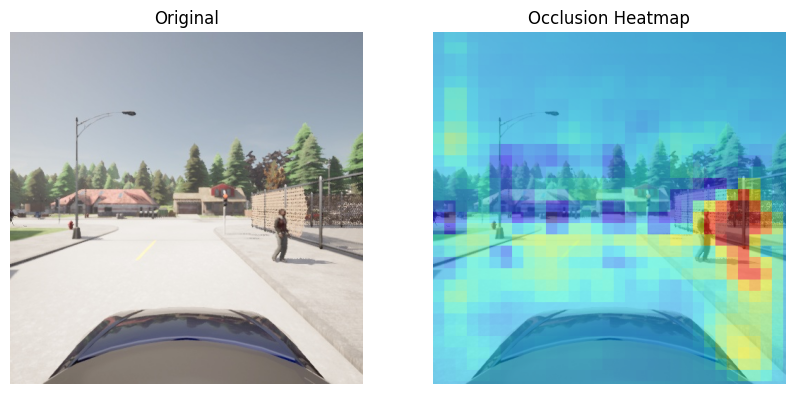

In [44]:
#Ploting Pedestrain
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(image_ped)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(image)

plt.imshow(
    heatmap_ped,
    cmap="jet",
    alpha=0.5
)

plt.title("Occlusion Heatmap")

plt.axis("off")

plt.show()

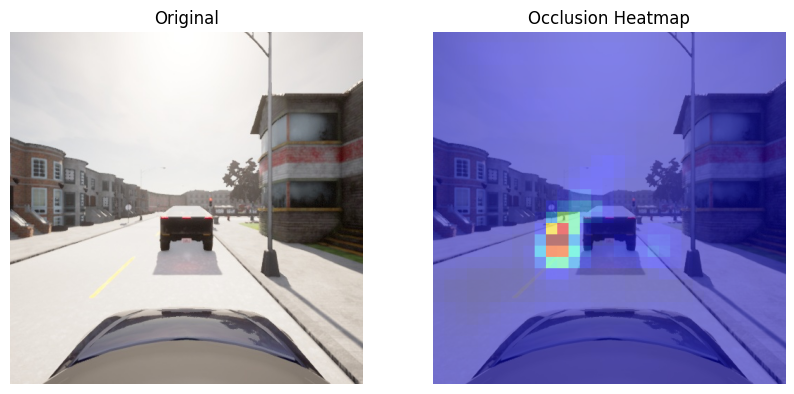

In [45]:
#Ploting Vehicle
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(image_veh)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(image_veh)

plt.imshow(
    heatmap_veh,
    cmap="jet",
    alpha=0.5
)

plt.title("Occlusion Heatmap")

plt.axis("off")

plt.show()

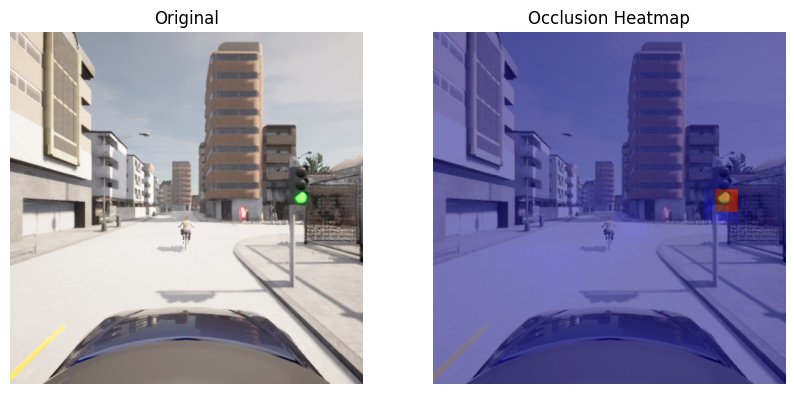

In [46]:
#Ploting Traffic Light
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(image_TL)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(image_TL)

plt.imshow(
    heatmap_TL,
    cmap="jet",
    alpha=0.5
)

plt.title("Occlusion Heatmap")

plt.axis("off")

plt.show()

**Selecting Misclassified Images**

In [69]:

#Misclassified Images
#Loading one image
np = "/content/drive/MyDrive/MLS_DATA/test/rgb-front/000740.jpg"
nv= "/content/drive/MyDrive/MLS_DATA/test/rgb-front/000000.jpg"
ntl= "/content/drive/MyDrive/MLS_DATA/test/rgb-front/000130.jpg"
image_ped = Image.open(np).convert("RGB")
image_veh = Image.open(nv).convert("RGB")
image_TL = Image.open(ntl).convert("RGB")

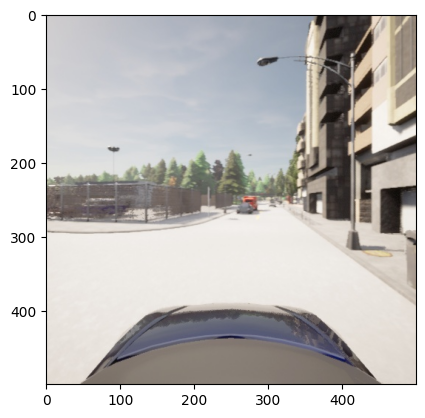

In [70]:
plt.imshow(image_TL)

In [71]:
#Predicting Pedestrain
img_tensor = transform(image_ped)

img_tensor = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():

    output = model_ped(img_tensor)

    prob = torch.sigmoid(output)

print("Original Score Pedestrain:", prob.item())

#Predicting Vehicle

img_tensor = transform(image_veh)

img_tensor = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():

    output = model_veh(img_tensor)

    prob = torch.sigmoid(output)

print("Original Score Vehicle:", prob.item())

#Predicting Pedestrain

img_tensor = transform(image_TL)

img_tensor = img_tensor.unsqueeze(0).to(device)

with torch.no_grad():

    output = model_TL(img_tensor)

    prob = torch.sigmoid(output)

print("Original Score Traffic Light:", prob.item())

Original Score Pedestrain: 0.27515554428100586
Original Score Vehicle: 0.08014322817325592
Original Score Traffic Light: 0.6385430693626404


In [72]:
#Generate heat maps
heatmap_noped = occlusion_heatmap(
    image_ped,
    model_ped,
    transform,
    device
)
heatmap_noveh = occlusion_heatmap(
    image_veh,
    model_veh,
    transform,
    device
)
heatmap_noTL = occlusion_heatmap(
    image_TL,
    model_TL,
    transform,
    device
)

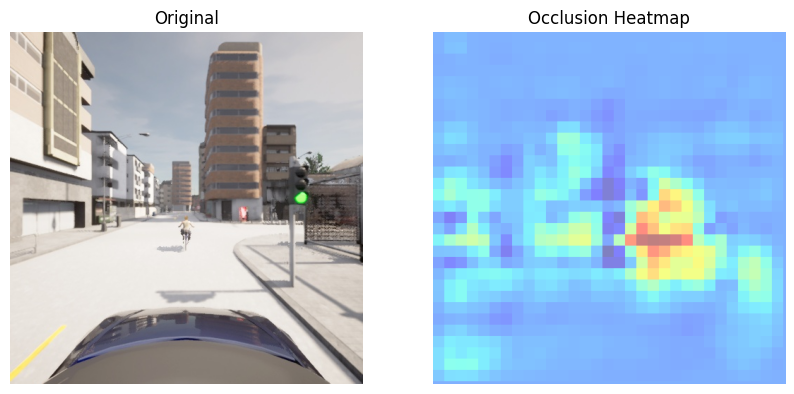

In [73]:
#Ploting No Pedestrain
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(image_ped)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    heatmap_noped,
    cmap="jet",
    alpha=0.5
)

plt.title("Occlusion Heatmap")

plt.axis("off")

plt.show()

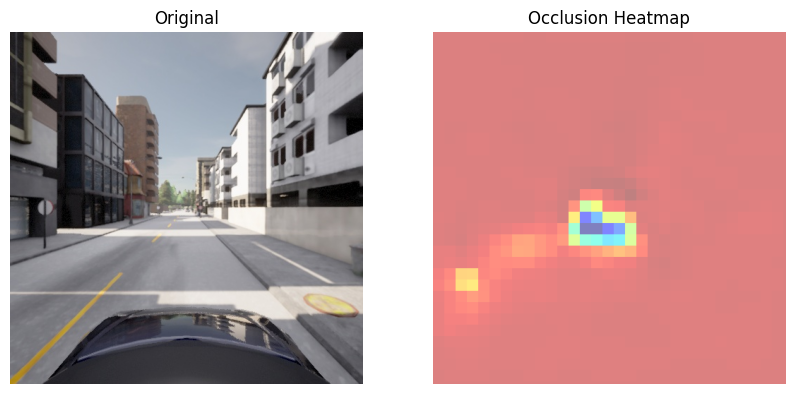

In [74]:
#Ploting No Vehicle
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(image_veh)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    heatmap_noveh,
    cmap="jet",
    alpha=0.5
)

plt.title("Occlusion Heatmap")

plt.axis("off")

plt.show()

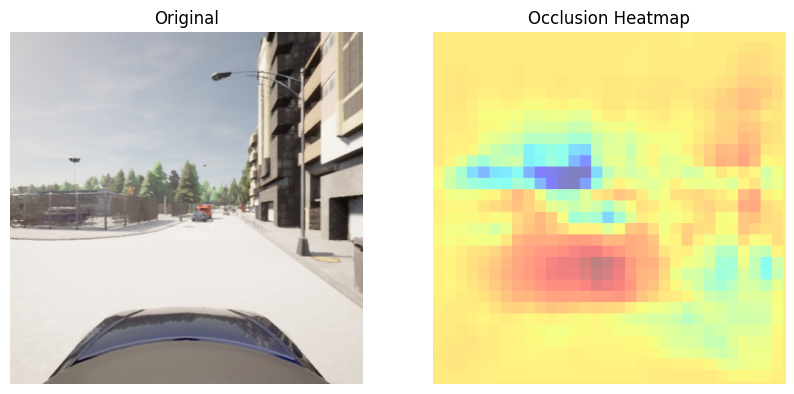

In [75]:
#Ploting No Traffic Light
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(image_TL)

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    heatmap_noTL,
    cmap="jet",
    alpha=0.5
)

plt.title("Occlusion Heatmap")

plt.axis("off")

plt.show()